# Instal

In [107]:
!pip3 install pandas
!pip3 install duckdb

!pip3 install matplotlib 
!pip3 install seaborn

In [108]:
import pandas as pd
import duckdb 

import matplotlib.pyplot as plt 
import seaborn as sns

# Andmete laadimine

In [109]:
penguins = sns.load_dataset("penguins") 
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [110]:
duckdb.sql("SUMMARIZE penguins").df() 

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,species,VARCHAR,Adelie,Gentoo,3,NaN,NaN,NaN,NaN,NaN,344,0.00
1,island,VARCHAR,Biscoe,Torgersen,3,NaN,NaN,NaN,NaN,NaN,344,0.00
2,bill_length_mm,DOUBLE,32.1,59.6,186,43.92192982456142,5.459583713926537,39.262499999999996,44.382,48.51875,344,0.58
3,bill_depth_mm,DOUBLE,13.1,21.5,80,17.151169590643278,1.974793156816781,15.565625,17.318,18.671875,344,0.58
4,flipper_length_mm,DOUBLE,172.0,231.0,51,200.91520467836258,14.061713679356952,190.0,197.06,213.46875,344,0.58
5,body_mass_g,DOUBLE,2700.0,6300.0,77,4201.754385964912,801.9545356980948,3552.34375,4030.5,4769.53125,344,0.58
6,sex,VARCHAR,Female,Male,2,NaN,NaN,NaN,NaN,NaN,344,3.20


In [111]:
penguins_not_null = penguins.dropna() 
penguins_not_null

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [112]:
penguins_not_null = penguins_not_null.rename(columns={
    "bill_length_mm": "bill_length",
    "bill_depth_mm": "bill_depth",
    "flipper_length_mm": "flipper_length",
    "body_mass_g": "body_mass"
})

print(penguins_not_null)

    species     island  bill_length  bill_depth  flipper_length  body_mass  \
0    Adelie  Torgersen         39.1        18.7           181.0     3750.0   
1    Adelie  Torgersen         39.5        17.4           186.0     3800.0   
2    Adelie  Torgersen         40.3        18.0           195.0     3250.0   
4    Adelie  Torgersen         36.7        19.3           193.0     3450.0   
5    Adelie  Torgersen         39.3        20.6           190.0     3650.0   
..      ...        ...          ...         ...             ...        ...   
338  Gentoo     Biscoe         47.2        13.7           214.0     4925.0   
340  Gentoo     Biscoe         46.8        14.3           215.0     4850.0   
341  Gentoo     Biscoe         50.4        15.7           222.0     5750.0   
342  Gentoo     Biscoe         45.2        14.8           212.0     5200.0   
343  Gentoo     Biscoe         49.9        16.1           213.0     5400.0   

        sex  
0      Male  
1    Female  
2    Female  
4    Fe

In [113]:
duckdb.sql(""" 
    SELECT 
           island,
           species,
           count(*) AS count
    FROM penguins_not_null
    GROUP BY island, species
""").df()

,island,species,count
0,Dream,Adelie,55
1,Dream,Chinstrap,68
2,Torgersen,Adelie,47
3,Biscoe,Adelie,44
4,Biscoe,Gentoo,119


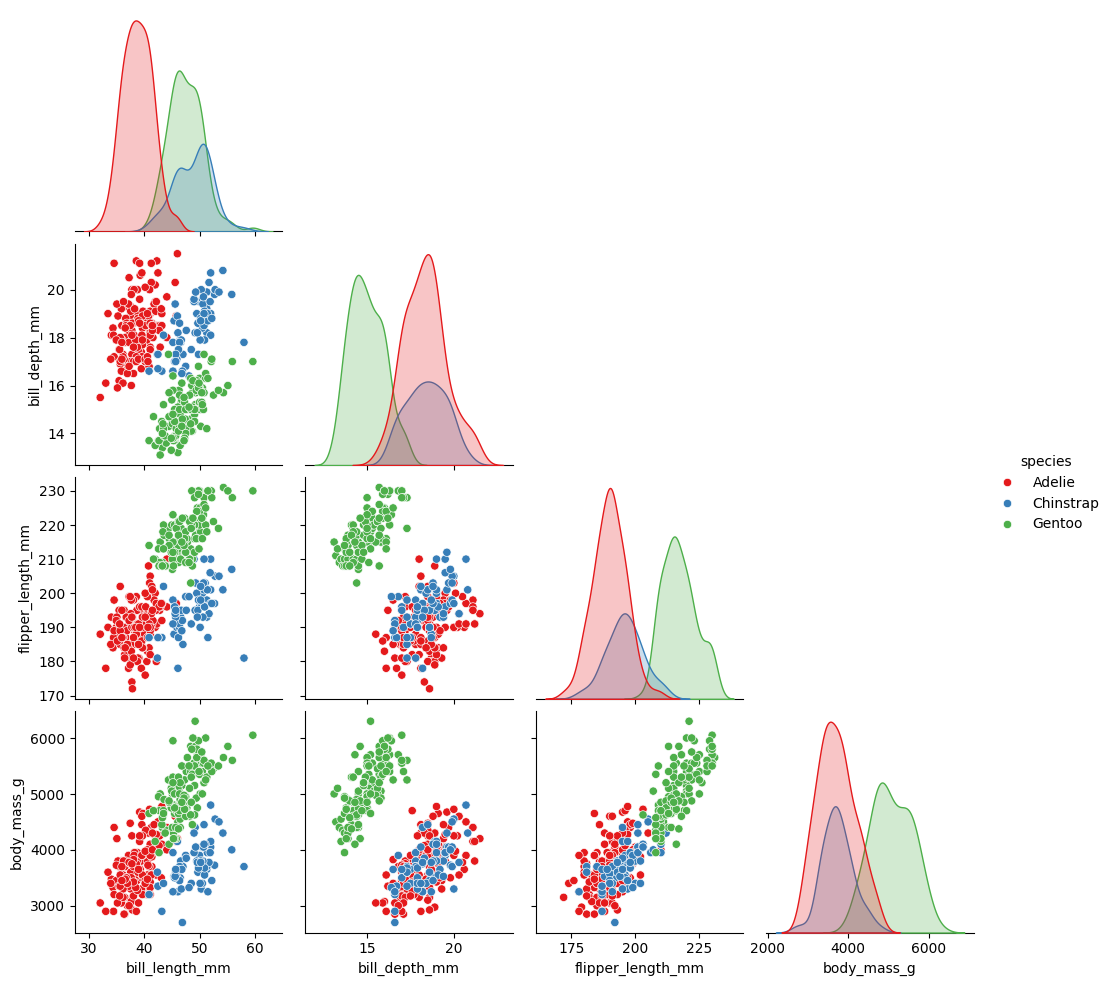

In [114]:
sns.pairplot(penguins, corner=True, hue="species", palette="Set1")

<Axes: xlabel='body_mass', ylabel='island'>

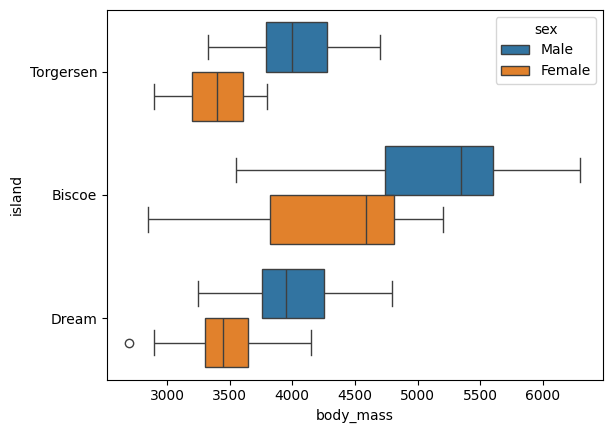

In [115]:
sns.boxplot(penguins_not_null, x="body_mass", y="island", hue="sex")

<Axes: >

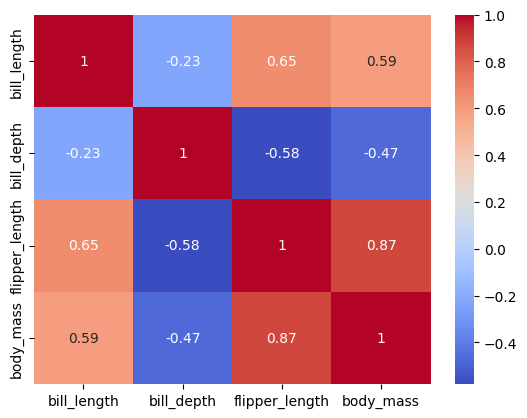

In [116]:
corr = penguins_not_null.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

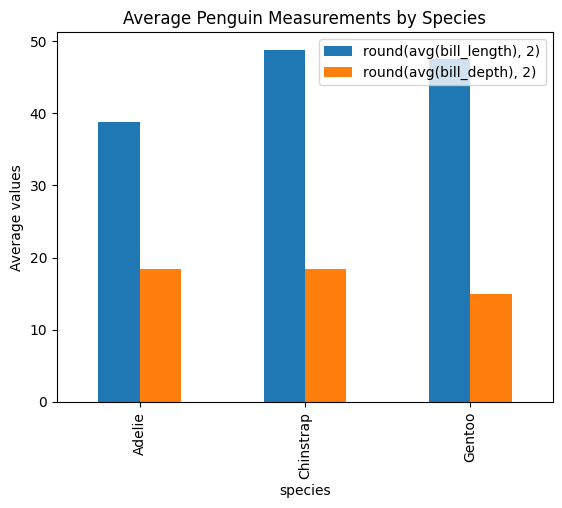

In [117]:
df= duckdb.sql(""" 
    SELECT
        species,
        ROUND(AVG(bill_length), 2),
        ROUND(AVG(bill_depth), 2),
    FROM penguins_not_null
    GROUP BY species
""").df() 

df.set_index("species").plot(kind="bar")

plt.ylabel("Average values")
plt.title("Average Penguin Measurements by Species")
plt.show()

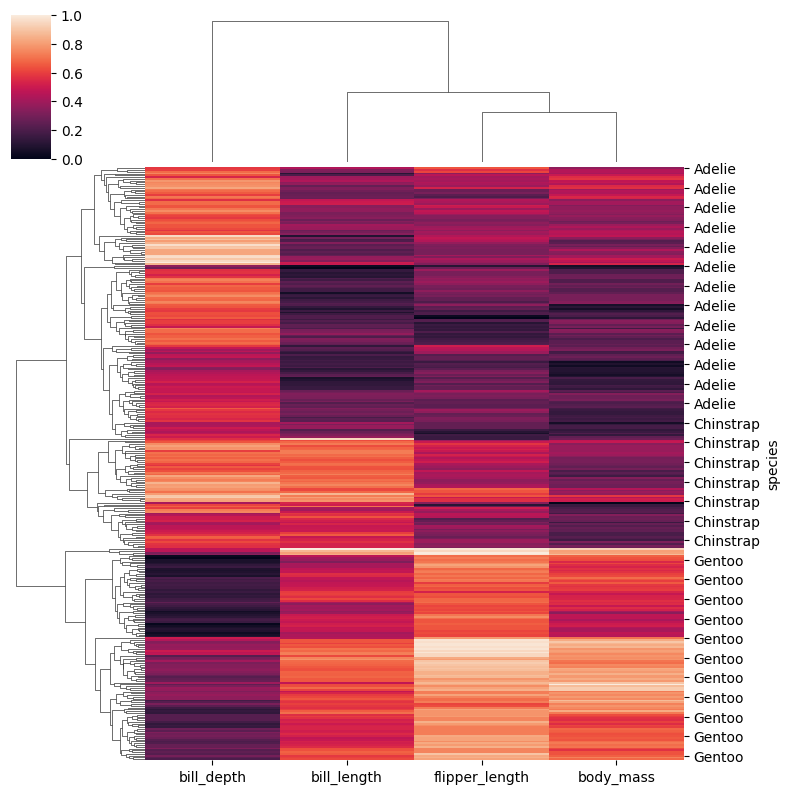

In [118]:
sns.clustermap(
    penguins_not_null[["bill_length", "bill_depth", 
                        "flipper_length", "body_mass", "species"]].set_index("species"),
    standard_scale = 1,
    figsize = (8,8)
)

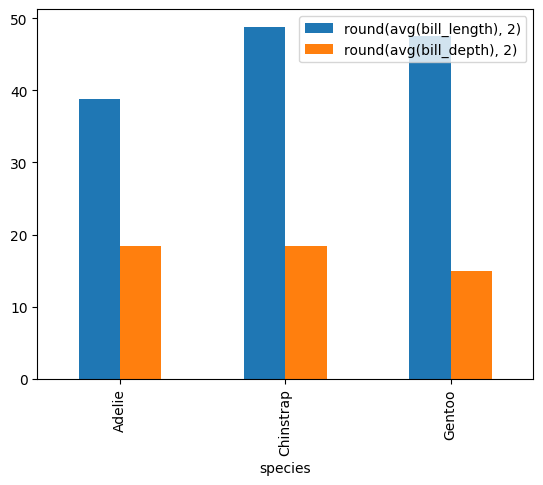

In [119]:
df.groupby("species").mean(numeric_only=True).plot(kind="bar")
plt.show()

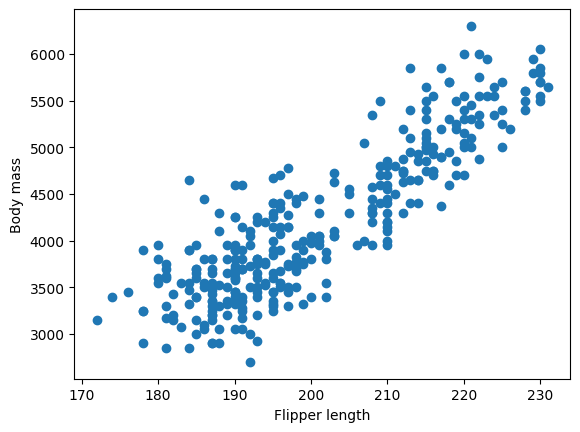

In [120]:
plt.scatter(penguins_not_null["flipper_length"], penguins_not_null["body_mass"])
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.show()